In [50]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
#Load Data 
df=pd.read_csv(r"C:\Users\dassh\Downloads\Healthcare Fraud Detection\healthcare_fraud_dataset.csv")

In [52]:
df.head(10)

,claim_id,patient_id,provider_id,hospital_id,treatment_type,claim_amount,approved_amount,claim_status,diagnosis_code,length_of_stay,num_procedures,num_medications,insurance_type,city,fraud_flag
0,1,1102,221,15,Consultation,24829.0,40443,Rejected,D1,14,4.0,6,Private,Mumbai,0
1,2,1435,256,33,Surgery,7203.0,4663,Rejected,D3,12,2.0,2,Private,Delhi,0
2,3,1860,265,27,Consultation,30370.0,42244,Pending,D4,14,4.0,8,Private,Delhi,0
3,4,1270,273,32,Therapy,NaN,15028,Rejected,D1,4,1.0,6,Government,Mumbai,0
4,5,1106,297,15,Consultation,15386.0,22823,Rejected,D3,2,2.0,9,Government,Bangalore,0
5,6,1071,215,38,Surgery,5434.0,18077,Pending,D4,8,3.0,6,Private,Bangalore,0
6,7,1700,250,34,Surgery,47998.0,42911,Pending,D4,8,2.0,6,Private,Delhi,0
7,8,1020,238,26,Therapy,39474.0,22631,Pending,D1,13,2.0,2,Government,Mumbai,0
8,9,1614,285,33,Therapy,29644.0,4910,Approved,D4,4,4.0,5,Private,Bangalore,0
9,10,1121,275,20,Therapy,43493.0,36500,Pending,D2,14,2.0,9,Private,Mumbai,0


In [53]:
# Data Cleaning
df.isnull().sum()

claim_id             0
patient_id           0
provider_id          0
hospital_id          0
treatment_type       0
claim_amount       200
approved_amount      0
claim_status         0
diagnosis_code       0
length_of_stay       0
num_procedures     200
num_medications      0
insurance_type       0
city                 0
fraud_flag           0
dtype: int64

In [54]:
df.fillna({
    'claim_amount': df['claim_amount'].median(),
    'num_procedures': df['num_procedures'].median()
}, inplace=True)

,claim_id,patient_id,provider_id,hospital_id,treatment_type,claim_amount,approved_amount,claim_status,diagnosis_code,length_of_stay,num_procedures,num_medications,insurance_type,city,fraud_flag
0,1,1102,221,15,Consultation,24829.0,40443,Rejected,D1,14,4.0,6,Private,Mumbai,0
1,2,1435,256,33,Surgery,7203.0,4663,Rejected,D3,12,2.0,2,Private,Delhi,0
2,3,1860,265,27,Consultation,30370.0,42244,Pending,D4,14,4.0,8,Private,Delhi,0
3,4,1270,273,32,Therapy,27215.0,15028,Rejected,D1,4,1.0,6,Government,Mumbai,0
4,5,1106,297,15,Consultation,15386.0,22823,Rejected,D3,2,2.0,9,Government,Bangalore,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,1576,226,10,Consultation,27215.0,13457,Rejected,D2,9,4.0,8,Government,Bangalore,0
3996,3997,1841,209,38,Therapy,13036.0,20957,Pending,D1,8,3.0,4,Government,Bangalore,0
3997,3998,1852,233,14,Consultation,45364.0,32619,Rejected,D4,3,2.0,7,Private,Bangalore,0
3998,3999,1516,235,44,Therapy,29369.0,23828,Pending,D4,3,4.0,8,Government,Bangalore,0


In [55]:
# Drop Rows (if small%)
df.dropna(inplace=True)


In [56]:
# Detect Fraud Patterns
df.groupby('fraud_flag')['claim_amount'].mean()

fraud_flag
0    27408.579181
1    27118.657216
Name: claim_amount, dtype: float64

In [57]:
df.groupby('provider_id')['fraud_flag'].mean().sort_values(ascending=False)

provider_id
232    0.233333
277    0.225000
254    0.205128
252    0.200000
246    0.192308
         ...   
204    0.000000
282    0.000000
269    0.000000
270    0.000000
299    0.000000
Name: fraud_flag, Length: 100, dtype: float64

In [58]:
# Checking Columns
df.columns

Index(['claim_id', 'patient_id', 'provider_id', 'hospital_id',
       'treatment_type', 'claim_amount', 'approved_amount', 'claim_status',
       'diagnosis_code', 'length_of_stay', 'num_procedures', 'num_medications',
       'insurance_type', 'city', 'fraud_flag'],
      dtype='str')

In [59]:
# create random claim dates
df['claim_date'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(
    np.random.randint(0, 365, len(df)), unit='D'
)

# discharge date = claim_date + length_of_stay
df['discharge_date'] = df['claim_date'] + pd.to_timedelta(df['length_of_stay'], unit='D')

In [60]:
# Convert Dates
df['claim_date'] = pd.to_datetime(df['claim_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

In [61]:
# Feature Engineering
# Length of Stay 
df['length_of_stay']=(df['discharge_date']-df['claim_date']).dt.days

In [62]:
# Claim Difference
df['claim_diff']= df['claim_amount']-df['approved_amount']

Text(0.5, 1.0, 'Fraud vs Genuine')

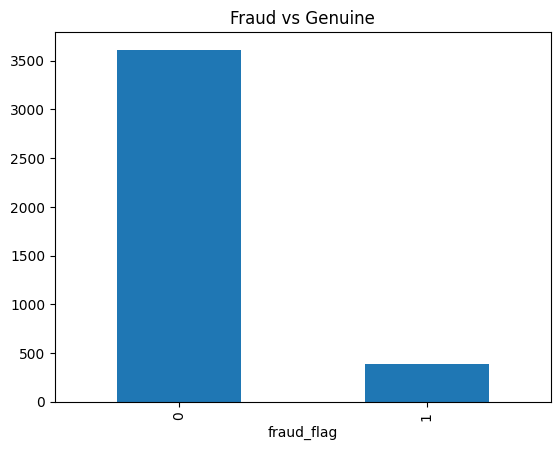

In [63]:
# Univariate Analysis
df['fraud_flag'].value_counts().plot(kind='bar')
plt.title("Fraud vs Genuine")

<Axes: xlabel='fraud_flag', ylabel='claim_amount'>

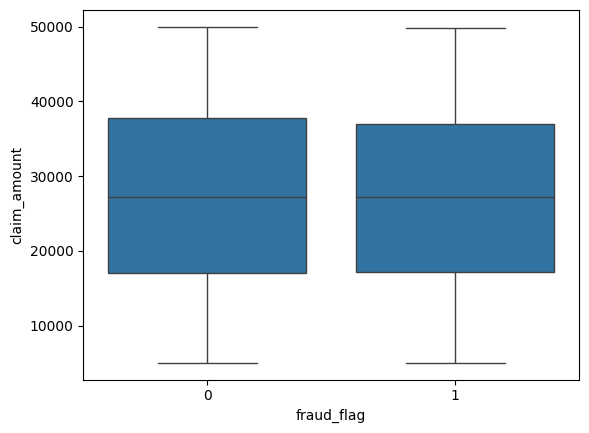

In [64]:
# Bivariate Analysis
sns.boxplot(x='fraud_flag' , y='claim_amount', data=df)

<Axes: xlabel='insurance_type', ylabel='count'>

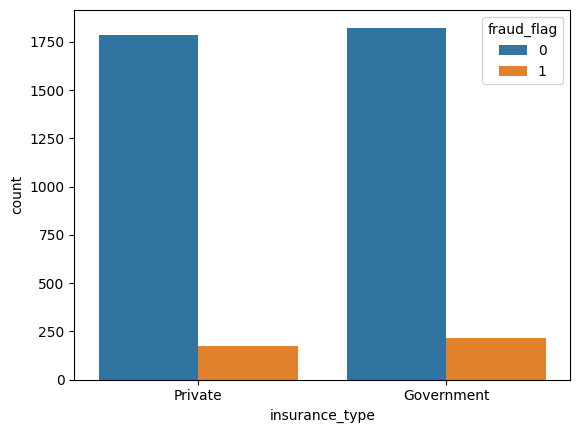

In [65]:
sns.countplot(x='insurance_type' , hue='fraud_flag' , data=df)

In [66]:
# Fraud Patterns
# High Claim Amount Fraud
fraud_cases=df[df['fraud_flag']==1]

In [67]:
fraud_cases.groupby('provider_id')['claim_amount'].mean().sort_values(ascending=False)

provider_id
240    48315.000000
249    44972.500000
296    42352.000000
222    41153.000000
235    39694.000000
           ...     
273    13156.000000
226    12343.750000
263    11756.666667
223    10274.000000
276     5823.000000
Name: claim_amount, Length: 93, dtype: float64

<Axes: >

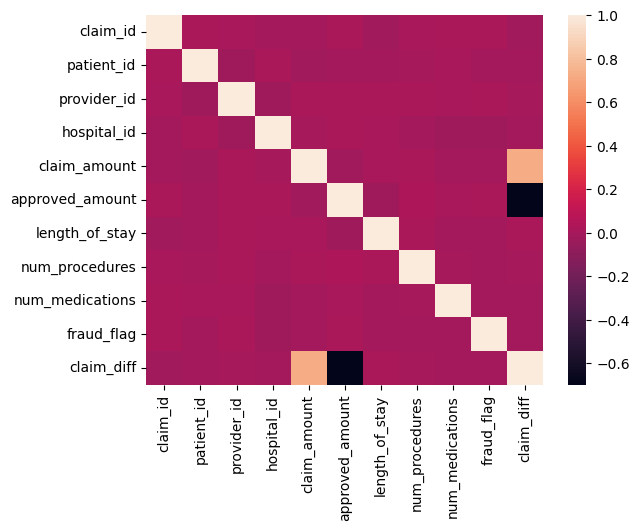

In [68]:
# Correlation
# Step 1: numeric correlation
corr = df.select_dtypes(include=np.number).corr()

# Step 2: visualize
sns.heatmap(corr)

In [70]:
# Connecting Python Script to PostgreSQL

from sqlalchemy import create_engine
from urllib.parse import quote_plus

# DB credentials
username = "postgres"
password = quote_plus("Shiva@2001")
host = "localhost"
port = "5432"
database = "healthcare_fraud_detection"

# Create connection
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Load to PostgreSQL
table_name = "healthcare_fraud"

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")


Data successfully loaded into table 'healthcare_fraud' in database 'healthcare_fraud_detection'.
